# Vehicle Price Prediction + Sellability Classification

## Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression , Ridge,Lasso,ElasticNet,LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Loading

In [2]:
car_df=pd.read_csv('../data/cardekho.csv')
print(f'Car shape: {car_df.shape}')
car_df.head()

Car shape: (8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


## EDA

In [3]:
car_df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [4]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [5]:
car_df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [6]:
car_df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [7]:
car_df.dropna(inplace=True)
car_df.shape

(7907, 12)

## Visualization

### Price Distribution 

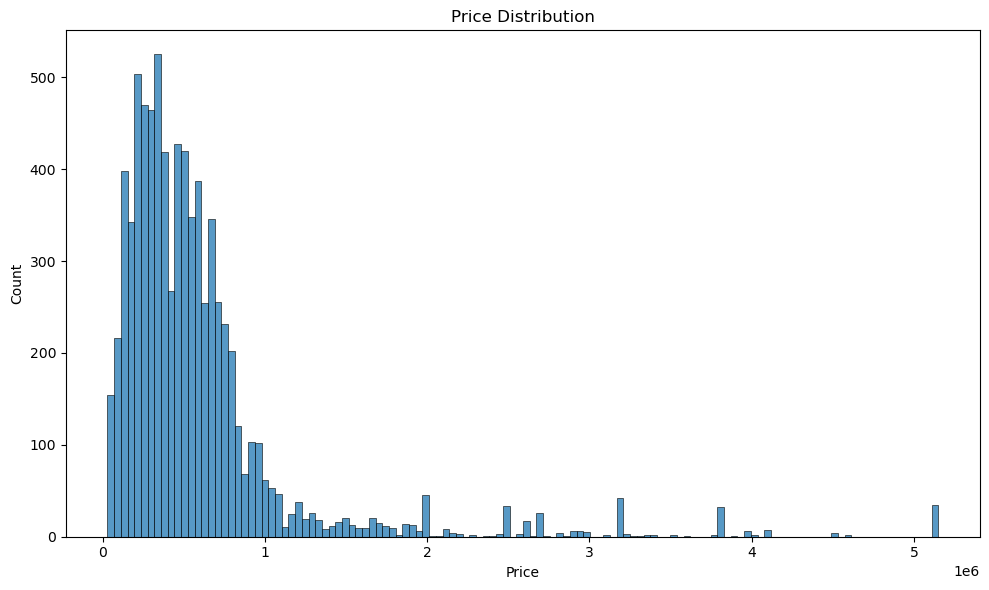

In [8]:
upper = car_df['selling_price'].quantile(0.99)
car_df = car_df[car_df['selling_price'] < upper]

plt.figure(figsize=(10,6))
ax=sns.histplot(x=car_df['selling_price'])
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.set_title("Price Distribution")
plt.tight_layout()
plt.show()

### Mileage vs Price

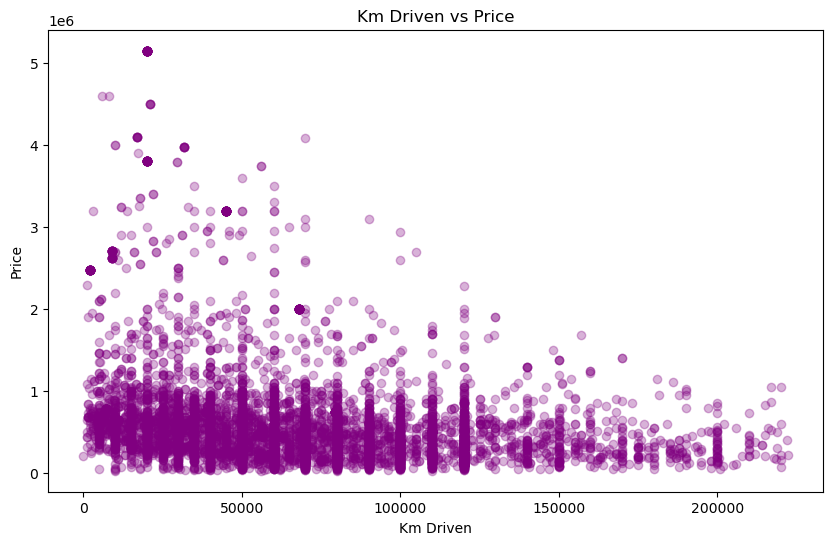

In [9]:
km_upper = car_df['km_driven'].quantile(0.99)
car_df = car_df[car_df['km_driven'] < km_upper]

plt.figure(figsize=(10, 6))
plt.scatter(car_df['km_driven'], car_df['selling_price'], alpha=0.3, color='purple')
plt.title('Km Driven vs Price')
plt.xlabel('Km Driven')
plt.ylabel('Price')
plt.show()

### Model Year vs Price

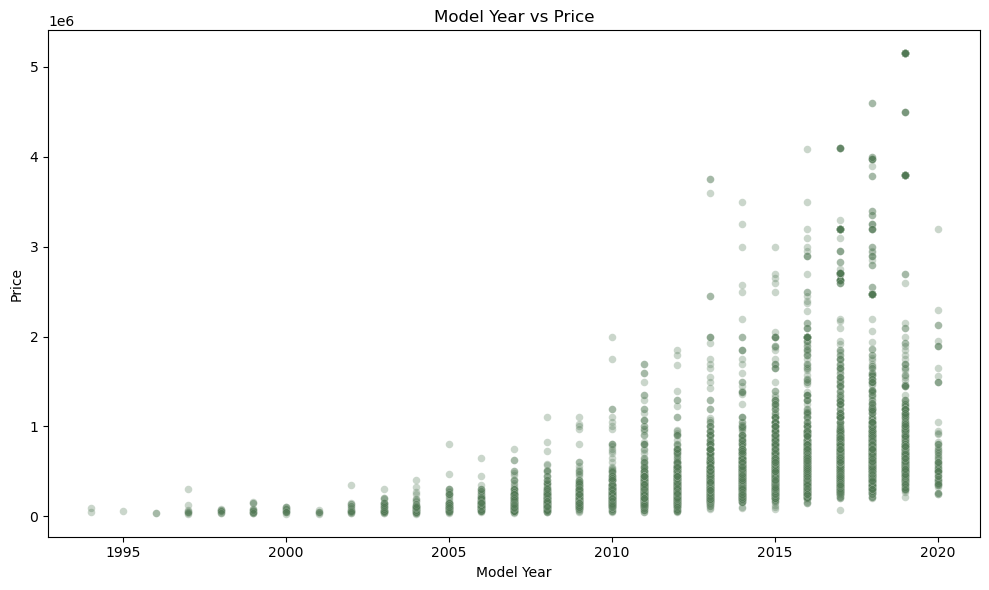

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(car_df['year'],car_df['selling_price'] ,alpha=0.3, color="#527955" , edgecolors='white', linewidths=0.2, s=30)
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.title("Model Year vs Price")
plt.tight_layout()
plt.show()

### Average Price by Fuel Type

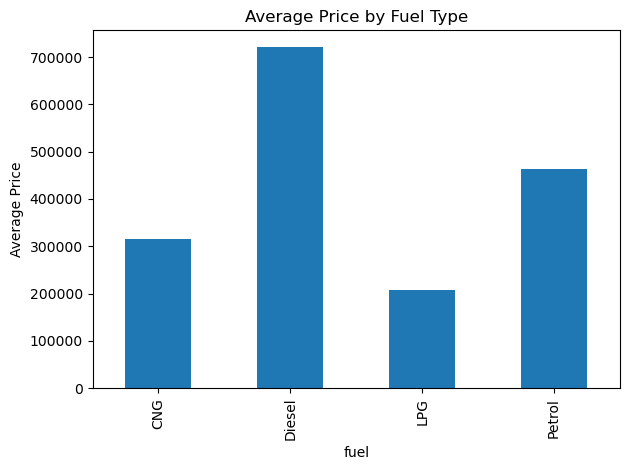

In [11]:
car_df.groupby('fuel')['selling_price'].mean().plot(kind="bar")
plt.ylabel("Average Price")
plt.title("Average Price by Fuel Type")
plt.tight_layout()
plt.show()

## Data Cleaning - Future Engineering

In [12]:
current_year=2026
car_df['car_age']=current_year - car_df['year']
car_df['brand'] = car_df['name'].str.split().str[0]
car_df['max_power'] = car_df['max_power'].str.extract(r'([\d.]+)').astype(float)
car_df['engine'] = car_df['engine'].astype(int)
car_df['seats'] = car_df['seats'].astype(int)

In [13]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5,20,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19,Maruti


In [14]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7743 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7743 non-null   object 
 1   year                7743 non-null   int64  
 2   selling_price       7743 non-null   int64  
 3   km_driven           7743 non-null   int64  
 4   fuel                7743 non-null   object 
 5   seller_type         7743 non-null   object 
 6   transmission        7743 non-null   object 
 7   owner               7743 non-null   object 
 8   mileage(km/ltr/kg)  7743 non-null   float64
 9   engine              7743 non-null   int64  
 10  max_power           7742 non-null   float64
 11  seats               7743 non-null   int64  
 12  car_age             7743 non-null   int64  
 13  brand               7743 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 907.4+ KB


In [15]:
car_df['mileage_per_year'] = car_df['km_driven'] / (car_df['car_age'] + 1)
car_df['power_per_engine'] = car_df['max_power'] / car_df['engine']

In [16]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7743 entries, 0 to 8127
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7743 non-null   object 
 1   year                7743 non-null   int64  
 2   selling_price       7743 non-null   int64  
 3   km_driven           7743 non-null   int64  
 4   fuel                7743 non-null   object 
 5   seller_type         7743 non-null   object 
 6   transmission        7743 non-null   object 
 7   owner               7743 non-null   object 
 8   mileage(km/ltr/kg)  7743 non-null   float64
 9   engine              7743 non-null   int64  
 10  max_power           7742 non-null   float64
 11  seats               7743 non-null   int64  
 12  car_age             7743 non-null   int64  
 13  brand               7743 non-null   object 
 14  mileage_per_year    7743 non-null   float64
 15  power_per_engine    7742 non-null   float64
dtypes: float64(

In [17]:
np.random.seed(42)
car_df['days_on_market'] = np.random.normal(45, 20, len(car_df)).clip(1, 180).astype(int)
car_df["is_fast_sale"]=np.where(car_df["days_on_market"]<=30,1,0)
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand,mileage_per_year,power_per_engine,days_on_market,is_fast_sale
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12,Maruti,11192.307692,0.059295,54,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12,Skoda,9230.769231,0.069105,42,0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5,20,Honda,6666.666667,0.052104,57,0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16,Hyundai,7470.588235,0.064470,75,0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19,Maruti,6000.000000,0.067951,40,0


In [18]:
car_df['is_fast_sale'].value_counts()

is_fast_sale
0    5839
1    1904
Name: count, dtype: int64

In [19]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand,mileage_per_year,power_per_engine,days_on_market,is_fast_sale
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5,12,Maruti,11192.307692,0.059295,54,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5,12,Skoda,9230.769231,0.069105,42,0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5,20,Honda,6666.666667,0.052104,57,0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5,16,Hyundai,7470.588235,0.064470,75,0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5,19,Maruti,6000.000000,0.067951,40,0


In [20]:
le = LabelEncoder()
for col in ['fuel', 'seller_type', 'transmission' , 'brand']:
    car_df[col] = le.fit_transform(car_df[col])
    print(f"\n{col}:")
    for i, cls in enumerate(le.classes_):
        print(f"  {cls} → {i}")


fuel:
  CNG → 0
  Diesel → 1
  LPG → 2
  Petrol → 3

seller_type:
  Dealer → 0
  Individual → 1
  Trustmark Dealer → 2

transmission:
  Automatic → 0
  Manual → 1

brand:
  Ambassador → 0
  Ashok → 1
  Audi → 2
  BMW → 3
  Chevrolet → 4
  Daewoo → 5
  Datsun → 6
  Fiat → 7
  Force → 8
  Ford → 9
  Honda → 10
  Hyundai → 11
  Isuzu → 12
  Jaguar → 13
  Jeep → 14
  Kia → 15
  Land → 16
  Lexus → 17
  MG → 18
  Mahindra → 19
  Maruti → 20
  Mercedes-Benz → 21
  Mitsubishi → 22
  Nissan → 23
  Opel → 24
  Renault → 25
  Skoda → 26
  Tata → 27
  Toyota → 28
  Volkswagen → 29
  Volvo → 30


In [21]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 0
}
car_df['owner'] = car_df['owner'].map(owner_map)

In [22]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7743 entries, 0 to 8127
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7743 non-null   object 
 1   year                7743 non-null   int64  
 2   selling_price       7743 non-null   int64  
 3   km_driven           7743 non-null   int64  
 4   fuel                7743 non-null   int64  
 5   seller_type         7743 non-null   int64  
 6   transmission        7743 non-null   int64  
 7   owner               7743 non-null   int64  
 8   mileage(km/ltr/kg)  7743 non-null   float64
 9   engine              7743 non-null   int64  
 10  max_power           7742 non-null   float64
 11  seats               7743 non-null   int64  
 12  car_age             7743 non-null   int64  
 13  brand               7743 non-null   int64  
 14  mileage_per_year    7743 non-null   float64
 15  power_per_engine    7742 non-null   float64
 16  days_on_mar

In [23]:
car_df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             1
seats                 0
car_age               0
brand                 0
mileage_per_year      0
power_per_engine      1
days_on_market        0
is_fast_sale          0
dtype: int64

In [24]:
car_df.dropna(inplace=True)
car_df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
car_age               0
brand                 0
mileage_per_year      0
power_per_engine      0
days_on_market        0
is_fast_sale          0
dtype: int64

In [25]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand,mileage_per_year,power_per_engine,days_on_market,is_fast_sale
0,Maruti Swift Dzire VDI,2014,450000,145500,1,1,1,1,23.40,1248,74.00,5,12,20,11192.307692,0.059295,54,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,1,1,1,2,21.14,1498,103.52,5,12,26,9230.769231,0.069105,42,0
2,Honda City 2017-2020 EXi,2006,158000,140000,3,1,1,3,17.70,1497,78.00,5,20,10,6666.666667,0.052104,57,0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,1,1,1,1,23.00,1396,90.00,5,16,11,7470.588235,0.064470,75,0
4,Maruti Swift VXI BSIII,2007,130000,120000,3,1,1,1,16.10,1298,88.20,5,19,20,6000.000000,0.067951,40,0


## Train-test-split

In [26]:
X=car_df.drop(["selling_price","days_on_market","is_fast_sale" , "name"],axis=1)
y=car_df["selling_price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Model

In [27]:
# Linear Regression

lr=LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

In [28]:
y_pred=lr.predict(X_test)

print("------ Linear Regression Evaluation -------")
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

------ Linear Regression Evaluation -------
MAE: 221647.1092185929
RMSE: 364721.3203969555
R2: 0.72859353609798


In [29]:
# Polynomial Regression

poly_model=Pipeline([
    ("poly",PolynomialFeatures(degree=2,include_bias=False)),
    ("linear",LinearRegression())
])

poly_model.fit(X_train,y_train)

poly_pred=poly_model.predict(X_test)

print("------ Polynomial Regression Evaluation -------")
print("Polynomial R2:",r2_score(y_test,poly_pred))
print("Polynomial RMSE:",np.sqrt(mean_squared_error(y_test,poly_pred)))

------ Polynomial Regression Evaluation -------
Polynomial R2: 0.9190429865017354
Polynomial RMSE: 199194.9378298637


In [30]:
train_score=poly_model.score(X_train,y_train)
test_score=poly_model.score(X_test,y_test)

print("Train R2:",train_score)
print("Test R2:",test_score)

Train R2: 0.9204787271340241
Test R2: 0.9190429865017354


In [31]:
# Ridge Regression

ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

ridge_pred=ridge.predict(X_test)

print("------ Ridge Regression Evaluation -------")
print("Ridge R2:",r2_score(y_test,ridge_pred))
print("Ridge RMSE:",np.sqrt(mean_squared_error(y_test,ridge_pred)))

alphas= [0.01,0.1,1,10,100]   # best alpha= 0.01

for a in alphas:
    model=Ridge(alpha=a)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    print(a,r2_score(y_test,pred),np.sqrt(mean_squared_error(y_test,pred)))


------ Ridge Regression Evaluation -------
Ridge R2: 0.7285035342021062
Ridge RMSE: 364781.7885393336
0.01 0.7285926472602446 364721.9176152428
0.1 0.7285846372736862 364727.29955510865
1 0.7285035342021062 364781.7885393336
10 0.7276182804163468 365376.0166281886
100 0.7192299880216273 370959.432382835


In [32]:
# Lasso Regression

lasso=Lasso(alpha=1.0,max_iter=10000)
lasso.fit(X_train,y_train)

lasso_pred=lasso.predict(X_test)

print("------ Lasso Regression Evaluation -------")
print("Lasso R2:",r2_score(y_test,lasso_pred))
print("Lasso RMSE:",np.sqrt(mean_squared_error(y_test,lasso_pred)))

------ Lasso Regression Evaluation -------
Lasso R2: 0.7285924814674105
Lasso RMSE: 364722.0290128717


c:\Users\Funda\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.323e+12, tolerance: 2.379e+11
  model = cd_fast.enet_coordinate_descent(


In [33]:
coef_df=pd.DataFrame({
"feature":X.columns,
"coef":lasso.coef_
})

print(coef_df[coef_df["coef"]==0])

Empty DataFrame
Columns: [feature, coef]
Index: []


In [34]:
# ElasticNet Regression

elastic=ElasticNet(alpha=1.0,l1_ratio=0.5,max_iter=10000)
elastic.fit(X_train,y_train)

elastic_pred=elastic.predict(X_test)

print("------ ElasticNet Regression Evaluation -------")
print("ElasticNet R2:",r2_score(y_test,elastic_pred))
print("ElasticNet RMSE:",np.sqrt(mean_squared_error(y_test,elastic_pred)))

ratios= [0.1,0.3,0.5,0.7,0.9]

for r in ratios:
    model=ElasticNet(alpha=1.0,l1_ratio=r,max_iter=10000)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    print(r,r2_score(y_test,pred),np.sqrt(mean_squared_error(y_test,pred)))

------ ElasticNet Regression Evaluation -------
ElasticNet R2: 0.665625824115628
ElasticNet RMSE: 404825.0913865732
0.1 0.6306530000556851 425469.4148382088
0.3 0.6480818434560728 415309.52831127896
0.5 0.665625824115628 404825.0913865732
0.7 0.6832246711873788 394027.68153941067
0.9 0.702449885938816 381883.69729778095


In [43]:
## Model Comparison

results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression", "Ridge", "Lasso", "ElasticNet"],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, poly_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, poly_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred))
    ]
})

print(results.sort_values("R2", ascending=False).to_string(index=False))


                Model       R2          RMSE
Polynomial Regression 0.919043 199194.937830
    Linear Regression 0.728594 364721.320397
                Lasso 0.728592 364722.029013
                Ridge 0.728504 364781.788539
           ElasticNet 0.665626 404825.091387


In [59]:
## Estimating Saleability with Logistic Regression


# Target: is_fast_sale (1 = easy to sell, 0 = hard to sell)
X_cls = car_df.drop(["selling_price", "days_on_market", "is_fast_sale", "name"], axis=1)
y_cls = car_df["is_fast_sale"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

scaler_cls = StandardScaler()
X_train_c = scaler_cls.fit_transform(X_train_c)
X_test_c  = scaler_cls.transform(X_test_c)

print(f"Training set: {X_train_c.shape}, Test set: {X_test_c.shape}")
print(f"Class distribution:\n{y_cls.value_counts()}")


##  Logistic Regression: Model + Evaluation

log_model = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
log_model.fit(X_train_c, y_train_c)

cls_pred = log_model.predict(X_test_c)

print("------ Logistic Regression Evaluation -------")
print("Accuracy:", accuracy_score(y_test_c, cls_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_c, cls_pred))
print()
print("Classification Report:")
print(classification_report(y_test_c, cls_pred,
      target_names=["Hard to sell (0)", "Easy to sell (1)"]))


Training set: (6193, 14), Test set: (1549, 14)
Class distribution:
is_fast_sale
0    5838
1    1904
Name: count, dtype: int64
------ Logistic Regression Evaluation -------
Accuracy: 0.5022595222724339

Confusion Matrix:
[[569 576]
 [195 209]]

Classification Report:
                  precision    recall  f1-score   support

Hard to sell (0)       0.74      0.50      0.60      1145
Easy to sell (1)       0.27      0.52      0.35       404

        accuracy                           0.50      1549
       macro avg       0.51      0.51      0.47      1549
    weighted avg       0.62      0.50      0.53      1549



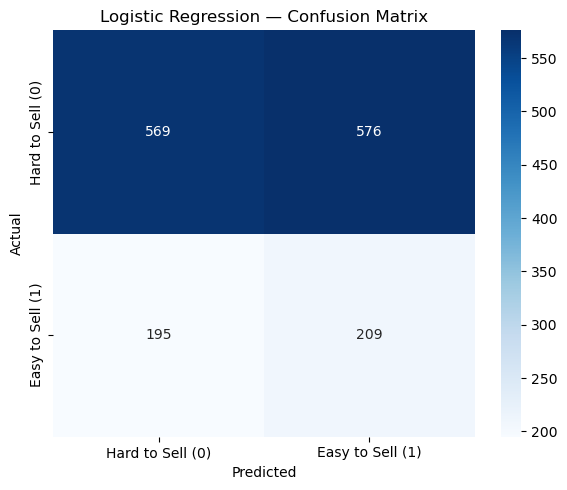

In [55]:
cm = confusion_matrix(y_test_c, cls_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Hard to Sell (0)", "Easy to Sell (1)"],
            yticklabels=["Hard to Sell (0)", "Easy to Sell (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


In [56]:
##  Price Gap Calculation

# Predict on the full dataset using the polynomial model
X_full = car_df.drop(["selling_price", "days_on_market", "is_fast_sale", "name"], axis=1)
X_full_scaled = scaler.transform(X_full)

car_df_analysis = car_df.copy()
car_df_analysis["predicted_price"] = poly_model.predict(X_full_scaled)
car_df_analysis["price_gap"] = car_df_analysis["selling_price"] - car_df_analysis["predicted_price"]

print("Price Gap Statistics:")
print(car_df_analysis["price_gap"].describe())
print()
print(f"Cars priced BELOW market (price_gap < 0): {(car_df_analysis['price_gap'] < 0).sum()}")
print(f"Cars priced ABOVE market (price_gap > 0): {(car_df_analysis['price_gap'] > 0).sum()}")


Price Gap Statistics:
count    7.742000e+03
mean    -8.180434e+02
std      1.799419e+05
min     -1.668978e+06
25%     -6.974576e+04
50%     -2.248535e+03
75%      6.948348e+04
max      2.263621e+06
Name: price_gap, dtype: float64

Cars priced BELOW market (price_gap < 0): 3938
Cars priced ABOVE market (price_gap > 0): 3804


In [57]:
## is_good_deal + Crosstab

# is_good_deal: priced below market → 1 (good deal)
car_df_analysis["is_good_deal"] = np.where(car_df_analysis["price_gap"] < 0, 1, 0)

print("is_good_deal distribution:")
print(car_df_analysis["is_good_deal"].value_counts())
print()

# Relationship analysis
crosstab = pd.crosstab(
    car_df_analysis["is_good_deal"],
    car_df_analysis["is_fast_sale"],
    rownames=["is_good_deal (0=Expensive, 1=Good Deal)"],
    colnames=["is_fast_sale (0=Hard, 1=Easy)"]
)
print(crosstab)


is_good_deal distribution:
is_good_deal
1    3938
0    3804
Name: count, dtype: int64

is_fast_sale (0=Hard, 1=Easy)               0    1
is_good_deal (0=Expensive, 1=Good Deal)           
0                                        2878  926
1                                        2960  978


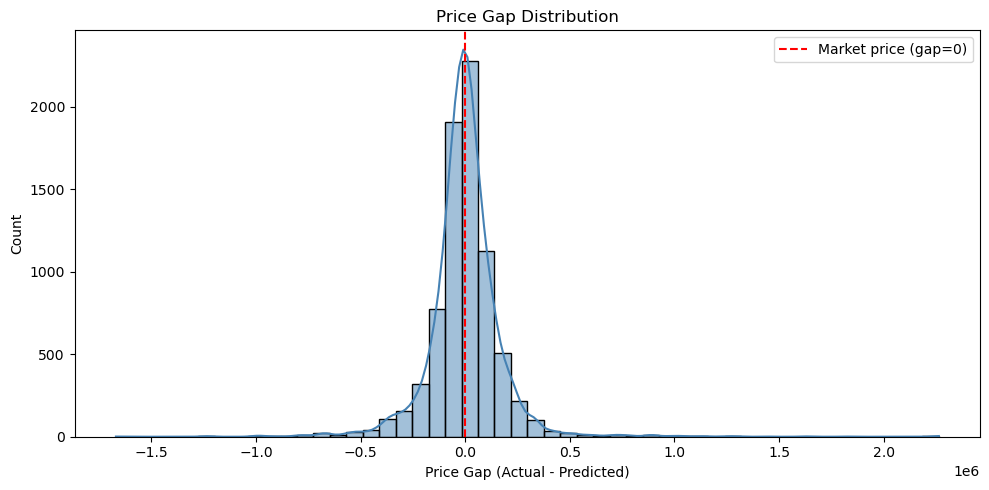

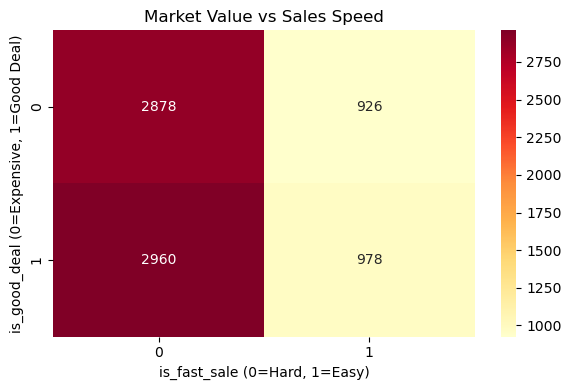

In [58]:
## Price Gap + Crosstab Visualization

# Price Gap distribution
plt.figure(figsize=(10, 5))
sns.histplot(car_df_analysis["price_gap"], bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Market price (gap=0)')
plt.xlabel("Price Gap (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Price Gap Distribution")
plt.legend()
plt.tight_layout()
plt.show()

# Crosstab heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    pd.crosstab(car_df_analysis["is_good_deal"], car_df_analysis["is_fast_sale"]),
    annot=True, fmt='d', cmap='YlOrRd'
)
plt.xlabel("is_fast_sale (0=Hard, 1=Easy)")
plt.ylabel("is_good_deal (0=Expensive, 1=Good Deal)")
plt.title("Market Value vs Sales Speed")
plt.tight_layout()
plt.show()
